<h1><center><span style="border-style:solid;border-width:1px;border-radius:5px;
    padding:5px;background-color:yellow;box-shadow: 6px 6px 6px black;">SQL et Python</span></center></h1>

Le module <code>sqlite3</code> permet de créer et interroger une base de données à partir de Python.

In [1]:
import sqlite3

**Création d'une table**<br>
On va créer la table suivante, qui représente une version simplifiée du bulletin des élèves d'un lycée.
Les attributs sont l'id de l'élève (clé primaire), le nom de l'élève, le prénom de l'élève, sa moyenne, un mot de passe et l'adresse de l'élève :

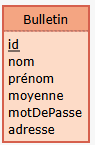

In [2]:
connexion = sqlite3.connect('maBase.db') # connexion à la base de données
# celle-ci est créée si elle n'existe pas

# Récupération d'un curseur (objet qui envoie les requêtes et lit les résultats)
c = connexion.cursor()

# Exécution d'une commande SQL, pour créer une nouvelle table dans la base
c.execute("CREATE TABLE IF NOT EXISTS "
          + "Bulletin(id INTEGER PRIMARY KEY, Nom TEXT, Prénom TEXT, moyenne REAL, motDePasse TEXT, adresse TEXT);")

# insertion d'un enregistrement (une ligne) dans la table
c.execute("INSERT INTO Bulletin VALUES(1,'Simpson', 'Bart', 12, 'azerty', 'London');")

# Sauvegarde des modifications (obligatoire sinon les modifications sont perdues à la fermeture)
connexion.commit()

c.execute("SELECT * FROM Bulletin;")
print(c.fetchall())   
# la méthode fetchall renvoie le résultat de la dernière requête
# (toutes les lignes sont placées dans une liste de tuples)
# fetch signifie "aller chercher"

# Fermeture de la connexion à la base de données (pour fermer proprement)
connexion.close()

[(1, 'Simpson', 'Bart', 12.0, 'azerty', 'London')]


Remarque 1 : Python et SQL ne sont pas les mêmes langages, donc ils n'utilisent pas les mêmes mots-clés.<br>
<ul>
<li>En Python, les types s'appellent <code>int</code>, <code>float</code>, <code>str</code>, etc.</li>
<li>En SQL, les types s’appellent <code>INTEGER</code>, <code>REAL</code>, <code>TEXT</code>, etc.</li>
</ul>
Remarque 2 : On stocke ici les mots de passe en clair pour simplifier, mais dans une vraie application, on ne fait jamais ça (on stocke un mot de passe chiffré / haché). 

<div class="alert alert-info" style="border:solid 1px; border-radius: 5px"><strong>Exercice 1 : </strong><br>
    1- Remplir la table avec trois élèves supplémentaires.<br> 
    2- Afficher le contenu de la table <em>Bulletin</em> avec la commande SQL <code>SELECT</code>.<br>     
</div>

In [3]:
# Votre programme en Python ici
# Votre programme en Python ici
connexion = sqlite3.connect('maBase.db')
c = connexion.cursor()

c.execute("SELECT * FROM Bulletin;")
c.fetchall()
c.execute("INSERT INTO bulletin VALUES(2,'Turing', 'Alan', 19.9, '3EAV4', 'Cambridge');")
c.execute("INSERT INTO bulletin VALUES(3,'Einstein', 'Albert', 19.5, '', 'Berlin');")
c.execute("INSERT INTO bulletin VALUES(4,'Sawyer', 'Tom', 8.2, 'Joe', 'Missouri');")
c.execute("SELECT * FROM Bulletin;")
print(c.fetchall())
connexion.commit()
connexion.close()

[(1, 'Simpson', 'Bart', 12.0, 'azerty', 'London'), (2, 'Turing', 'Alan', 19.9, '3EAV4', 'Cambridge'), (3, 'Einstein', 'Albert', 19.5, '', 'Berlin'), (4, 'Sawyer', 'Tom', 8.2, 'Joe', 'Missouri')]


<div class="alert alert-info" style="border:solid 1px; border-radius: 5px"><strong>Exercice 2 : </strong>
Écrire un programme qui demande à l'utilisateur de saisir un nom de famille, puis qui affiche les informations de toutes les personnes qui portent ce nom.  
</div>

In [4]:
# Votre programme ici :
nom = input("Veuillez saisir le nom d'un élève : ")
connexion = sqlite3.connect('maBase.db')
c = connexion.cursor()
c.execute("SELECT * FROM Bulletin;")
listeElèves = c.fetchall()
connexion.close()
for e in listeElèves:
    if e[1] == nom:
        print(e)

Veuillez saisir le nom d'un élève : Turing
(2, 'Turing', 'Alan', 19.9, '3EAV4', 'Cambridge')


<div class="alert alert-info" style="border:solid 1px; border-radius: 5px"><strong>Exercice 3 : </strong>
Écrire un programme qui génère une liste de dictionnaires Python à partir des données de la table <em>Bulletin</em>.</div>

In [5]:
# Votre programme ici :
connexion = sqlite3.connect('maBase.db')
c = connexion.cursor()
c.execute("SELECT * FROM Bulletin;")
listeElèves = c.fetchall()
connexion.close()

listeDico = []
for e in listeElèves:
    dico = {}
    dico['id'] = e[0]
    dico['nom'] = e[1]
    dico['prénom'] = e[2]
    dico['moyenne'] = e[3]
    dico['motDePasse'] = e[4]
    dico['adresse'] = e[5]
    listeDico.append(dico)

In [6]:
for e in listeDico:
    print(e)

{'id': 1, 'nom': 'Simpson', 'prénom': 'Bart', 'moyenne': 12.0, 'motDePasse': 'azerty', 'adresse': 'London'}
{'id': 2, 'nom': 'Turing', 'prénom': 'Alan', 'moyenne': 19.9, 'motDePasse': '3EAV4', 'adresse': 'Cambridge'}
{'id': 3, 'nom': 'Einstein', 'prénom': 'Albert', 'moyenne': 19.5, 'motDePasse': '', 'adresse': 'Berlin'}
{'id': 4, 'nom': 'Sawyer', 'prénom': 'Tom', 'moyenne': 8.2, 'motDePasse': 'Joe', 'adresse': 'Missouri'}


<div class="alert alert-info" style="border:solid 1px; border-radius: 5px"><strong>Exercice 4 : </strong>
Écrire un programme qui demande à l'utilisateur de saisir successivement un nom, un prénom, une moyenne, un mot de passe et une adresse, puis qui sauvegarde dans la base de données les valeurs saisies.<br>
    Ce programme pourrait être accessible aux professeurs par exemple.<br>
Ajouter ensuite quelques élèves dans la base de données avec cette méthode, puis afficher à nouveau le contenu de la base complétée.</div>

In [7]:
# Votre programme ici
nom = input("Veuillez saisir le nom de l'élève : ")
prénom = input("Veuillez saisir le prénom de l'élève : ")
moyenne = float(input("Veuillez saisir la moyenne de l'élève : "))
motDePasse = input("Veuillez saisir le mot de passe de l'élève : ")
adresse = input("Veuillez saisir l'adresse de l'élève : ")
connexion = sqlite3.connect('maBase.db')
c = connexion.cursor()
c.execute("SELECT * FROM Bulletin;")
listeElèves = c.fetchall()
idMax = 0
for e in listeElèves:
    if e[0] > idMax:
        idMax = e[0]
id = idMax + 1
commande = 'INSERT INTO Bulletin VALUES(' + str(id) + ',"' + nom + '","' + prénom + '",' + str(moyenne) + ',"' + motDePasse + '","' + adresse + '");'

print(commande)
c.execute(commande)
connexion.commit()
c.execute("SELECT * FROM Bulletin;")
listeElèves = c.fetchall()
connexion.close()
for e in listeElèves:
    print(e)

Veuillez saisir le nom de l'élève : Dupont
Veuillez saisir le prénom de l'élève : Lisa
Veuillez saisir la moyenne de l'élève : 15.3
Veuillez saisir le mot de passe de l'élève : fsdf@#'sdf54
Veuillez saisir l'adresse de l'élève : Paris
INSERT INTO Bulletin VALUES(5,"Dupont","Lisa",15.3,"fsdf@#'sdf54","Paris");
(1, 'Simpson', 'Bart', 12.0, 'azerty', 'London')
(2, 'Turing', 'Alan', 19.9, '3EAV4', 'Cambridge')
(3, 'Einstein', 'Albert', 19.5, '', 'Berlin')
(4, 'Sawyer', 'Tom', 8.2, 'Joe', 'Missouri')
(5, 'Dupont', 'Lisa', 15.3, "fsdf@#'sdf54", 'Paris')


<div class="alert alert-info" style="border:solid 1px; border-radius: 5px"><strong>Exercice 5 : </strong> <em>Faille de sécurité : l'injection SQL (usurpation d'identité)</em><br>
Le programme ci-dessous permet à un élève d'afficher les informations personnelles contenues dans son bulletin, à condition qu'il ait donné auparavant son nom et son mot de passe.<br>
1- Quelle requête va être réellement effectuée si un utilisateur malveillant fournit le mot de passe suivant : <code>' OR 1=1; --</code><br>
2- Que va-t-il alors se passer ?<br>
3- Comment remédier à ce problème ?<br>
</div>

1- La requête réelle est  : 
    <code>SELECT * FROM Bulletin WHERE nom='Sawyer' AND motDePasse='' OR 1=1; --';</code><br>
2- A cause de "OR 1=1", la requête est équivalente à la requête suivante : <code>SELECT * FROM Bulletin;</code><br>
   Les informations de tous les élèves vont donc s'afficher.<br>
3- Il faut éviter les concaténations de chaînes de caractères.<br>
   La méthode correcte est celle expliquée dans l'encadré en jaune plus bas.<br>
   Voir le deuxième programme ci-dessous.

In [ ]:
nom = input("Nom : ")
motDePasse = input("Mot de passe : ")
connexion = sqlite3.connect('maBase.db')
c = connexion.cursor()
requête = "SELECT * FROM Bulletin WHERE nom='" + nom + "' AND motDePasse='" + motDePasse + "';"
print(requête)
c.execute(requête)
print(c.fetchall())
connexion.close()

In [ ]:
# Version immnunisée contre l'injection SQL (et aussi beaucoup plus agréable à écrire)
nom = input("Nom : ")
motDePasse = input("Mot de passe : ")
connexion = sqlite3.connect('maBase.db')
c = connexion.cursor()
requête = "SELECT * FROM Bulletin WHERE nom=? AND motDePasse=?;"
c.execute(requête,[nom,motDePasse])
print(c.fetchall())
connexion.close()    

<div class="alert alert-info" style="border:solid 1px; border-radius: 5px"><strong>Exercice 6 : </strong> <em>Faille de sécurité : l'injection SQL (piratage d'une base de données)</em><br>
1- Écrire un programme qui permet à un élève de modifier son adresse à condition qu'il ait donné auparavant son nom et son mot de passe.<br>
2- Comment un utilisateur pourrait-il modifier sa moyenne de façon frauduleuse ?<br>
3- Comment remédier à ce problème ?<br>
</div>

In [ ]:
# Votre programme ici
nom = input("Veuillez saisir votre nom : ")
motDePasse = input("Veuillez saisir votre mot de passe : ")
connexion = sqlite3.connect('maBase.db')
c = connexion.cursor()
c.execute("SELECT * FROM Bulletin;")
listeElèves = c.fetchall()
authentifié = False
for e in listeElèves:
    if e[1] == nom and e[4] == motDePasse:
        authentifié = True
        break
if authentifié:
    print("Bienvenue!")
    print("Voici votre adresse : " + e[5])   
    nouvelleAdresse = input("Veuillez saisir votre nouvelle adresse : ")
    commande = 'UPDATE Bulletin SET adresse = "' + nouvelleAdresse + '" WHERE id=' + str(e[0]) + ';'
    print(commande)
    c.execute(commande)
else:
    print("Mot de passe incorrect")
connexion.commit()
connexion.close()

# nouvelle adresse à saisir pour modifier frauduleusement sa moyenne :
#                              Missouri", moyenne=20.0 WHERE nom='Sawyer'--

In [ ]:
# Version immnunisée contre l'injection SQL
nom = input("Veuillez saisir votre nom : ")
motDePasse = input("Veuillez saisir votre mot de passe : ")
connexion = sqlite3.connect('maBase.db')
c = connexion.cursor()
c.execute("SELECT * FROM Bulletin;")
listeElèves = c.fetchall()
authentifié = False
for e in listeElèves:
    if e[1] == nom and e[4] == motDePasse:
        authentifié = True
        break
if authentifié:
    print("Bienvenue!")
    print("Voici votre adresse : " + e[5])   
    nouvelleAdresse = input("Veuillez saisir votre nouvelle adresse : ")
    commande = 'UPDATE Bulletin SET adresse=? WHERE id=?;'    
    c.execute(commande,[nouvelleAdresse,e[0]])
else:
    print("Mot de passe incorrect")
connexion.commit()
connexion.close()

<div id="partie5" style="background-color: rgb(250,250,190); padding:10px; border:solid 2px; border-radius:5px;border-color:purple">
Comment rendre plus agréable la saisie de la commande SQL qui contient des variables Python :<br>
Il est possible de laisser dans la requête des "trous" dénotés par les caractères <code> ? </code>. Ces trous sont ensuite remplacés par les valeurs se trouvant dans la liste passée en second paramètre à <code>.execute()</code> (le premier trou est remplacé par la première valeur de la liste et ainsi de suite).<br>
Cette méthode a aussi l'avantage de prémunir contre l'injection SQL.
</div>

<div class="alert alert-info" style="border:solid 1px; border-radius: 5px"><strong>Exercice 7 : </strong> <em>Analogie entre tables et classes</em><br>
    1) Écrire une classe <code>Bulletin</code> correspondant à la table Bulletin, puis créer une instance pour chaque bulletin présent dans la base de données.<br><br>
2) On a l'analogie suivante entre une table d'une base de données et une classe Python :
<div style="text-align: center;">
    <ul style="display: inline-block; text-align: left;border:1px solid;background-color:rgb(235,194,240);">
        <li>Table Bulletin ↔ classe Bulletin</li>
        <li>Ligne ↔ objet / instance</li>
        <li>Colonne ↔ attribut d’instance</li>
    </ul>
</div>

Différence : on peut ajouter des méthodes à une classe, on ne peut pas faire cela avec une table.<br><br>
    Ajouter une méthode <code>mention</code> dans la classe Bulletin. Cette méthode devra renvoyer une chaîne de caractère, par exemple "Assez bien" si la moyenne du bulletin est comprise entre 14 et 16.
</div>

In [12]:
# Définition de votre classe Bulletin ici
class Bulletin:
    def __init__(self, identifiant, nom, prénom, moyenne, motDePasse, adresse):
        self.id = identifiant
        self.nom = nom
        self.prénom = prénom
        self.moyenne = moyenne
        self.motDePasse = motDePasse
        self.adresse = adresse
    
    def mention(self):
        if self.moyenne < 8:
            return "Recalé"
        elif self.moyenne < 10:
            return "Oral de rattrapage"
        elif self.moyenne < 12:
            return "Admis sans mention"
        elif self.moyenne < 14:
            return "Assez bien"
        elif self.moyenne < 16:
            return "Bien"
        elif self.moyenne < 18:
            return "Très bien"
        else:
            return "Félicitations"

def ligneVersInstance(ligne):
    return Bulletin(ligne["id"],ligne["nom"],ligne["prénom"],ligne["moyenne"],ligne["motDePasse"],ligne["adresse"])

In [13]:
listeInstances = []
for b in listeDico:    
    listeInstances.append(ligneVersInstance(b))

In [14]:
for e in listeInstances:
    print(vars(e))

{'id': 1, 'nom': 'Simpson', 'prénom': 'Bart', 'moyenne': 12.0, 'motDePasse': 'azerty', 'adresse': 'London'}
{'id': 2, 'nom': 'Turing', 'prénom': 'Alan', 'moyenne': 19.9, 'motDePasse': '3EAV4', 'adresse': 'Cambridge'}
{'id': 3, 'nom': 'Einstein', 'prénom': 'Albert', 'moyenne': 19.5, 'motDePasse': '', 'adresse': 'Berlin'}
{'id': 4, 'nom': 'Sawyer', 'prénom': 'Tom', 'moyenne': 8.2, 'motDePasse': 'Joe', 'adresse': 'Missouri'}


In [15]:
for e in listeInstances:
    print(e.nom,e.mention(),sep=" : ")

Simpson : Assez bien
Turing : Félicitations
Einstein : Félicitations
Sawyer : Oral de rattrapage
